# AQI Classification Notebook
## Data Loading, Preprocessing → Part 1: Random Forest → Part 2: XGBoost

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 1. Data Loading & Preprocessing

In [57]:
df = pd.read_csv('aqi_data.csv', skipinitialspace=True)
df

,date,pm25,pm10,no2,so2,co
0,2024/8/1,43.0,26.0,73.0,1.0,6.0
1,2024/8/2,45.0,21.0,66.0,1.0,5.0
2,2024/8/3,42.0,22.0,73.0,1.0,4.0
3,2024/8/4,40.0,18.0,96.0,2.0,5.0
4,2024/8/5,37.0,21.0,110.0,1.0,5.0
...,...,...,...,...,...,...
1626,2021/6/28,NaN,13.0,20.0,1.0,4.0
1627,2021/6/29,NaN,28.0,26.0,1.0,5.0
1628,2021/6/30,NaN,31.0,26.0,2.0,4.0
1629,2023/9/26,NaN,NaN,13.0,1.0,8.0


In [58]:
df['date'] = pd.to_datetime(df['date'])

In [59]:
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = all_dates.difference(df['date'])

print(f"Number of missing dates in sequence: {len(missing_dates)}")
print("First few missing dates:", missing_dates)

Number of missing dates in sequence: 15
First few missing dates: DatetimeIndex(['2020-03-01', '2020-03-23', '2020-03-24', '2020-03-25',
               '2020-03-26', '2020-06-03', '2020-06-04', '2020-06-05',
               '2020-06-06', '2020-06-07', '2020-06-13', '2020-06-14',
               '2020-10-18', '2022-01-07', '2022-01-08'],
              dtype='datetime64[us]', freq=None)


In [60]:
df_complete = df.set_index('date').reindex(all_dates).rename_axis('date').reset_index()
df_complete

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,NaN,NaN,NaN,NaN
1,2020-02-11,54.0,NaN,NaN,NaN,NaN
2,2020-02-12,167.0,NaN,NaN,NaN,NaN
3,2020-02-13,88.0,NaN,NaN,NaN,NaN
4,2020-02-14,89.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1641,2024-08-08,44.0,NaN,NaN,NaN,NaN
1642,2024-08-09,43.0,40.0,136.0,2.0,4.0
1643,2024-08-10,50.0,18.0,70.0,1.0,3.0
1644,2024-08-11,41.0,21.0,99.0,1.0,5.0


In [61]:
df_complete.isnull().sum()

date      0
pm25    207
pm10    366
no2     716
so2     301
co      292
dtype: int64

In [62]:
numeric_cols = ['pm25', 'pm10', 'no2', 'so2', 'co']
df_filled = df_complete.copy()
df_filled[numeric_cols] = df_filled[numeric_cols].interpolate(method='linear')
df_filled = df_filled.bfill().ffill()
df_filled.isnull().sum()

date    0
pm25    0
pm10    0
no2     0
so2     0
co      0
dtype: int64

In [63]:
df_filled[numeric_cols] = df_filled[numeric_cols].round(2)

In [64]:
df_filled

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,41.00,1.00,30.00,2.00
1,2020-02-11,54.0,41.00,1.00,30.00,2.00
2,2020-02-12,167.0,41.00,1.00,30.00,2.00
3,2020-02-13,88.0,41.00,1.00,30.00,2.00
4,2020-02-14,89.0,41.00,1.00,30.00,2.00
...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.67,121.33,1.67,3.67
1642,2024-08-09,43.0,40.00,136.00,2.00,4.00
1643,2024-08-10,50.0,18.00,70.00,1.00,3.00
1644,2024-08-11,41.0,21.00,99.00,1.00,5.00


In [65]:
df_w = pd.read_csv('almaty_weather.csv')
df_w = df_w.rename(columns={'ds': 'date'})
df_w['date'] = pd.to_datetime(df_w['date'])
df_w

,date,temp,wind_speed,humidity,pressure
0,2020-02-10,5.6,10.1,78.29,918.64
1,2020-02-11,-3.5,16.2,90.83,924.91
2,2020-02-12,-1.2,20.8,68.04,918.59
3,2020-02-13,-0.6,12.3,86.62,927.45
4,2020-02-14,-2.5,11.0,91.33,932.97
...,...,...,...,...,...
1641,2024-08-08,27.1,7.8,31.33,917.87
1642,2024-08-09,29.0,28.9,31.12,915.04
1643,2024-08-10,27.2,21.6,40.04,918.13
1644,2024-08-11,24.2,9.4,50.92,919.62


In [66]:
df_final = pd.merge(df_filled, df_w, on = 'date', how = 'inner')
df_final

,date,pm25,pm10,no2,so2,co,temp,wind_speed,humidity,pressure
0,2020-02-10,17.0,41.00,1.00,30.00,2.00,5.6,10.1,78.29,918.64
1,2020-02-11,54.0,41.00,1.00,30.00,2.00,-3.5,16.2,90.83,924.91
2,2020-02-12,167.0,41.00,1.00,30.00,2.00,-1.2,20.8,68.04,918.59
3,2020-02-13,88.0,41.00,1.00,30.00,2.00,-0.6,12.3,86.62,927.45
4,2020-02-14,89.0,41.00,1.00,30.00,2.00,-2.5,11.0,91.33,932.97
...,...,...,...,...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.67,121.33,1.67,3.67,27.1,7.8,31.33,917.87
1642,2024-08-09,43.0,40.00,136.00,2.00,4.00,29.0,28.9,31.12,915.04
1643,2024-08-10,50.0,18.00,70.00,1.00,3.00,27.2,21.6,40.04,918.13
1644,2024-08-11,41.0,21.00,99.00,1.00,5.00,24.2,9.4,50.92,919.62


In [67]:
numeric_cols.extend(['temp', 'wind_speed','humidity','pressure'])

In [68]:
numeric_cols

['pm25',
 'pm10',
 'no2',
 'so2',
 'co',
 'temp',
 'wind_speed',
 'humidity',
 'pressure']

### 1.2 Exploratory Data Analysis

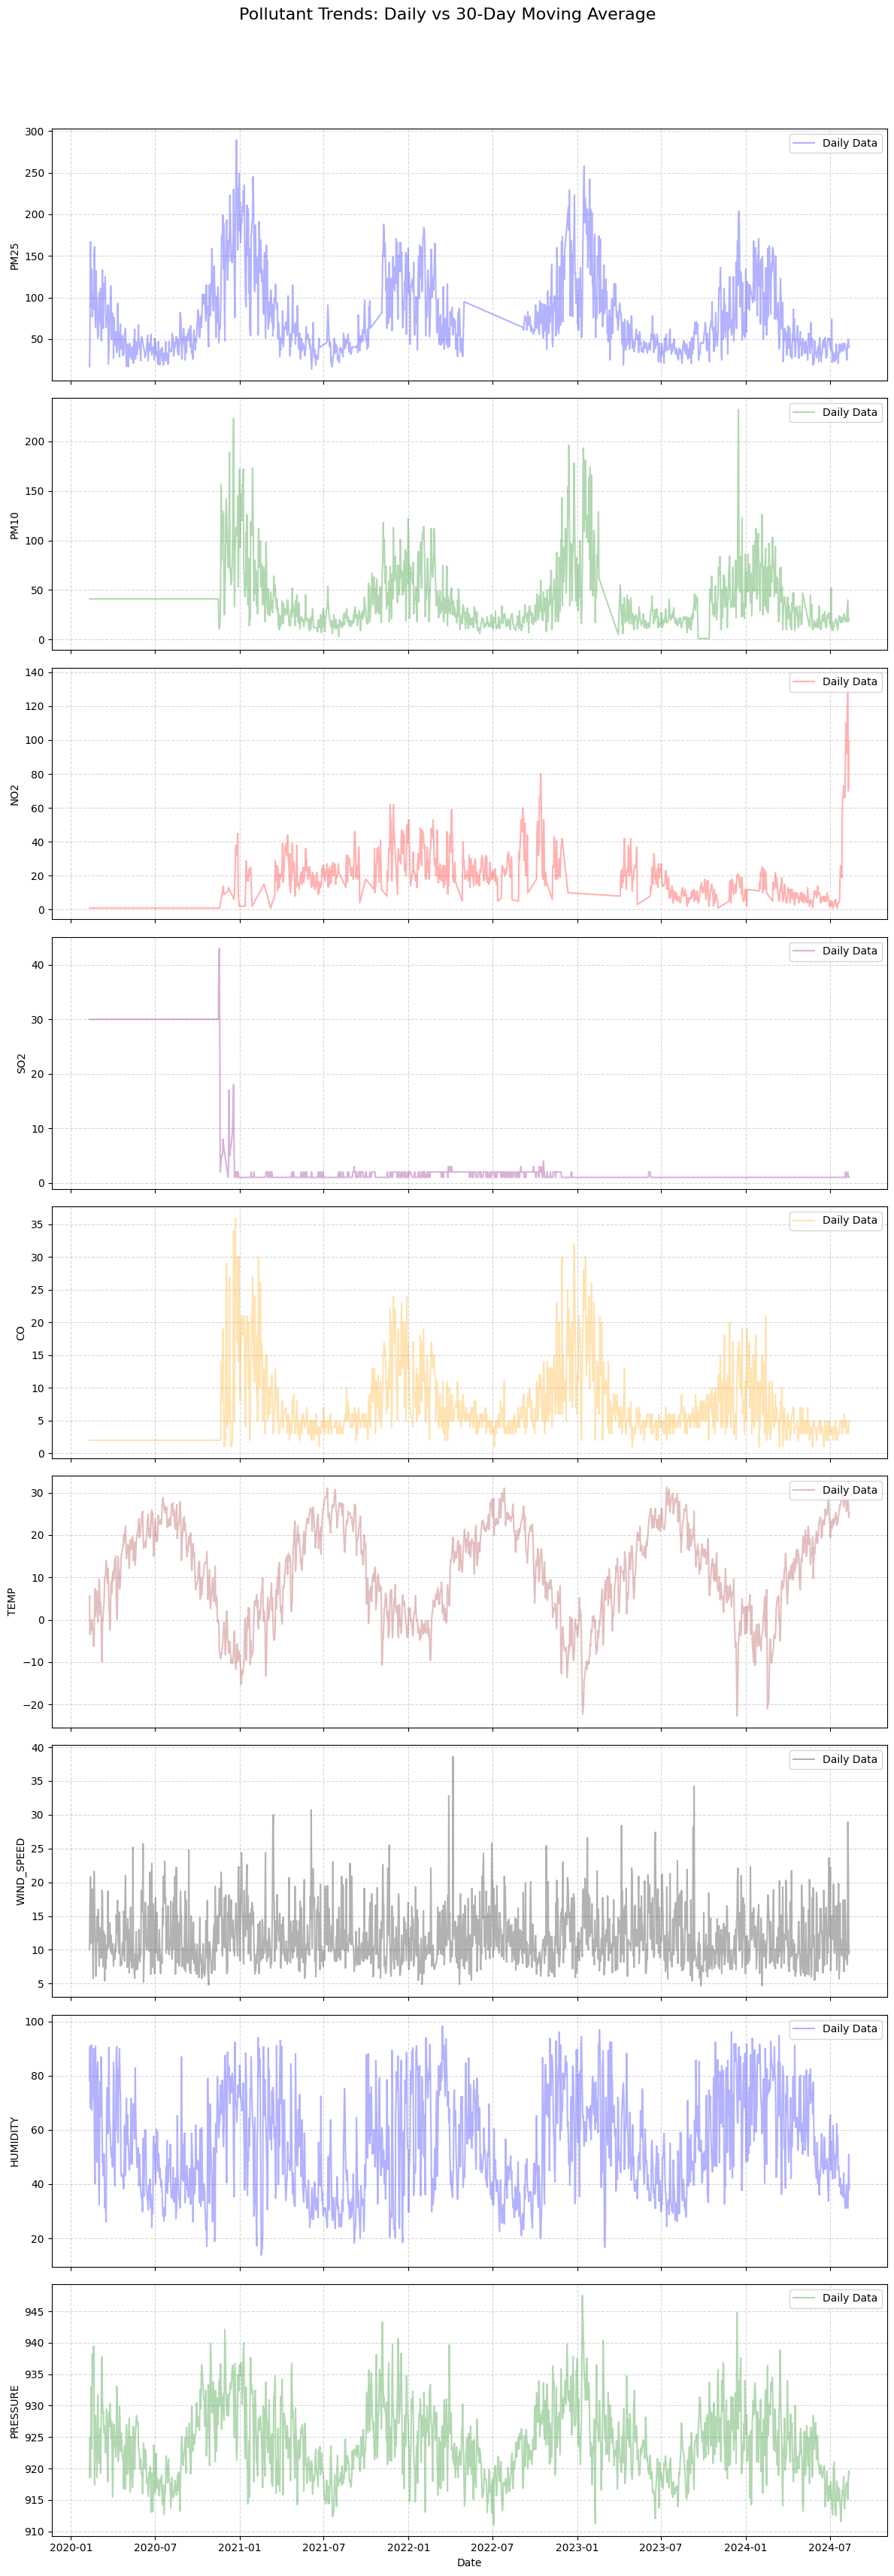

In [69]:
num_plots = len(numeric_cols)

fig, axes = plt.subplots(num_plots, 1, figsize=(12, 4 * num_plots), sharex=True)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'black', 'blue','green','orange']

if num_plots == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    axes[i].plot(df_final['date'], df_final[col], color=colors[i % len(colors)], alpha=0.3, label='Daily Data')
    axes[i].set_ylabel(col.upper())
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.suptitle('Pollutant Trends: Daily vs 30-Day Moving Average', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

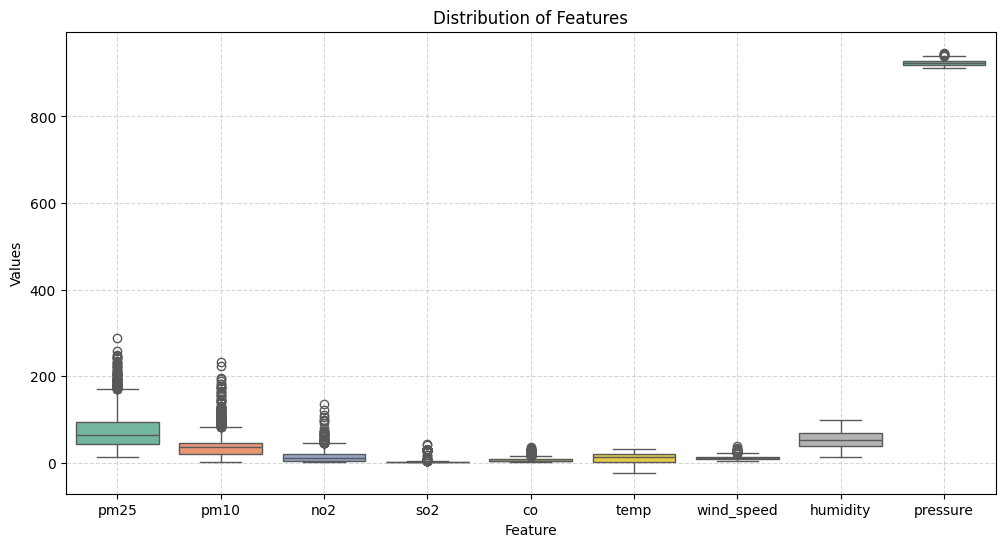

In [70]:
fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_final[numeric_cols].melt(var_name='Feature', value_name='Values')
sns.boxplot(data=df_plot, x='Feature', y='Values', palette='Set2')
plt.title('Distribution of Features')
plt.ylabel('Values')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [71]:
from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [72]:
def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [73]:
df_final = df_final.set_index('date')
df_final

,pm25,pm10,no2,so2,co,temp,wind_speed,humidity,pressure
date,,,,,,,,,
2020-02-10,17.0,41.00,1.00,30.00,2.00,5.6,10.1,78.29,918.64
2020-02-11,54.0,41.00,1.00,30.00,2.00,-3.5,16.2,90.83,924.91
2020-02-12,167.0,41.00,1.00,30.00,2.00,-1.2,20.8,68.04,918.59
2020-02-13,88.0,41.00,1.00,30.00,2.00,-0.6,12.3,86.62,927.45
2020-02-14,89.0,41.00,1.00,30.00,2.00,-2.5,11.0,91.33,932.97
...,...,...,...,...,...,...,...,...,...
2024-08-08,44.0,32.67,121.33,1.67,3.67,27.1,7.8,31.33,917.87
2024-08-09,43.0,40.00,136.00,2.00,4.00,29.0,28.9,31.12,915.04
2024-08-10,50.0,18.00,70.00,1.00,3.00,27.2,21.6,40.04,918.13
